In [1]:
%load_ext autoreload
%autoreload 2

In [307]:
from collections import defaultdict
import copy
import os
import pprint
import functools
from pathlib import Path

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches
import matplotlib.colors
import seaborn as sns
font_scale = 7
sns.set_theme(style='whitegrid', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [5]:
dataset_cols = """
    Dataset.id,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
"""

##### Lorenz '96

In [427]:
dataset_name = "Lorenz '96"
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join Lorenz96 on Dataset.id = Lorenz96.id
    where true
    and state_dimension = 1e6
    and use_predicted_state_perturbation = true
    and predicted_state_perturbation_std = 1e-2
""").pl()
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Kuramoto-Sivashinsky

In [405]:
dataset_name = 'Kuramoto-Sivashinsky'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
    where true
    and state_dimension = 1024
    and floating_point_precision = 32
    and use_predicted_state_perturbation = true
    and predicted_state_perturbation_std = 1e-2
""").pl()
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($64 \times 64$)

In [385]:
dataset_name = r'Navier-Stokes ($64 \times 64$)'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    where true
    and state_dimension = 3*64*64
    and use_predicted_state_perturbation = true
    and predicted_state_perturbation_std = 1e-2
""").pl()
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($256 \times 256$)

In [1]:
dataset_name = r'Navier-Stokes ($256 \times 256$)'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    where true
    and state_dimension = 3*256*256
    and time_step_count = 6000
    and time_step_size = 1e-4
    and observe_every_n_time_steps = 100
    and use_predicted_state_perturbation = true
    and predicted_state_perturbation_std = 1e-2
""").pl()
assert len(dataset_rows) == 1
dataset_multiple = 1

NameError: name 'duckdb' is not defined

### Models

In [428]:
sampling_time_step_counts = (5, 10, 20, 50, 100)

In [429]:
var = {
    'EnSF': [
        ['epsilon_alpha', r'$\epsilon_{\alpha}$'],
        ['epsilon_beta', r'$\epsilon_{\beta}$'],
    ],
    'EnFF-OT': [
        ['log10(sigma_min)', r'$\log_{10}(\sigma_{\min})$'],
        ['lambda', r'$\lambda$'],
    ],
}
var['EnFF-F2P'] = var['EnFF-OT']

##### EnsF

In [432]:
label = 'EnSF'
var1, var1_latex = var[label][0]
var2, var2_latex = var[label][1]
sampling_time_step_count = 50
ensf_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r} as label,
        {var1} as var1,
        {var2} as var2,
        sampling_time_step_count,
    from Model
    join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id
    join Bao2024EnsembleScoreMatching on ScoreMatchingMarginal.DiffusionPath = Bao2024EnsembleScoreMatching.id
    where true
    and sampling_time_step_count in {sampling_time_step_counts}
    and epsilon_alpha in (0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0)
    and epsilon_beta in (1e-3,5e-3,0.025,0.075,0.125,0.175,0.225,0.275)
""")
ensf_multiple = (
    len(sampling_time_step_counts)
    * 10  # epsilon_alpha
    * 8  # epsilon_beta
)

##### EnFF-OT

In [433]:
label = 'EnFF-OT'
var1, var1_latex = var[label][0]
var2, var2_latex = var[label][1]
sampling_time_step_count = 100
enff_ot_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r} as label,
        {var1} as var1,
        constant as var2,
        sampling_time_step_count,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    where true
    and sampling_time_step_count in {sampling_time_step_counts}
    and sigma_min in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
    and constant in (1e-3, 5e-3, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
""")
enff_ot_multiple = (
    len(sampling_time_step_counts)
    * 5  # sigma_min
    * 13  # constant as lambda
)

##### EnFF-F2P

In [434]:
label = 'EnFF-F2P'
var1, var1_latex = var[label][0]
var2, var2_latex = var[label][1]
sampling_time_step_count = 50
enff_f2p_rows = duckdb.sql(f"""
    select
        Model.id,
        {label!r} as label,
        {var1} as var1,
        constant as var2,
        sampling_time_step_count,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    where true
    and sampling_time_step_count in {sampling_time_step_counts}
    and sigma_min in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1)
    and constant in (1e-3, 5e-3, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0)
""")
enff_f2p_multiple = (
    len(sampling_time_step_counts)
    * 5  # sigma_min
    * 13  # constant as lambda
)

### General

In [435]:
rows = duckdb.sql(f"""
    select
        alt_id,
        model_rows.*,
        dataset_rows.*,
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join (
        select * from ensf_rows
        union
        select * from enff_ot_rows
        union
        select * from enff_f2p_rows
    ) as model_rows on Conf.Model = model_rows.id
    where true
    and rng_seed = 2376999025
""")
model_multiple = ensf_multiple + enff_ot_multiple + enff_f2p_multiple
assert len(rows) == dataset_multiple * model_multiple, f'{len(rows) = } != {dataset_multiple * model_multiple}'

In [436]:
filepaths = duckdb.sql("""
select format('~/out/dafm/runs/{}/dataset_metrics.csv', alt_id) as filepath from rows
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(filepath=filepaths.get_column('filepath'), exists=filepath_exists))
assert filepaths['exists'].any()
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(filepath) from filepaths where exists
)
""")

File path does not exist: '/home/ttransue/out/dafm/runs/psibz48r/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/c4hosl9t/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/6ikz26dj/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/bab76ige/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/hrv2e46f/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/fmm0k4le/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/if2d2blt/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/29oh92x2/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/xkcnmish/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/sepj1ddh/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/runs/faos8k42/dataset_metrics.csv'
File path does not exist: '/home/ttransue/out/dafm/run

In [437]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""")
logged_metrics.show(max_width=100)

┌──────────┬───────┬──────────┬───┬─────────────────────┬────────────────────┬─────────────────────┐
│  alt_id  │  id   │  label   │ … │       time_s        │        crps        │        rmse         │
│ varchar  │ int64 │ varchar  │   │       double        │       double       │       double        │
├──────────┼───────┼──────────┼───┼─────────────────────┼────────────────────┼─────────────────────┤
│ zzcz94bn │   785 │ EnFF-F2P │ … │   0.457946297999996 │    2275.2724609375 │  3.1397485733032227 │
│ zzcz94bn │   785 │ EnFF-F2P │ … │  0.4433350399999938 │     2273.701171875 │   3.137779474258423 │
│ zzcz94bn │   785 │ EnFF-F2P │ … │  0.4558628409999983 │   2271.11767578125 │    3.13434100151062 │
│ zzcz94bn │   785 │ EnFF-F2P │ … │ 0.45908005299997967 │   2268.36572265625 │  3.1306138038635254 │
│ zzcz94bn │   785 │ EnFF-F2P │ … │ 0.45628335899999684 │   2266.54345703125 │   3.128126382827759 │
│ zzcz94bn │   785 │ EnFF-F2P │ … │  0.4576242320000006 │  2266.245361328125 │  3.127712011

In [440]:
failed_before_finish = duckdb.sql(f"""
    select
        alt_id,
        count(*) as observation_step_count,
    from logged_metrics
    group by alt_id
    having observation_step_count < {observation_steps_back}
""")
failed_before_finish
# assert len(logged_metrics) > 0 and len(failed_before_finish) == 0, failed_before_finish

┌─────────┬────────────────────────┐
│ alt_id  │ observation_step_count │
│ varchar │         int64          │
├─────────┴────────────────────────┤
│              0 rows              │
└──────────────────────────────────┘

In [439]:
logged_metrics = duckdb.sql("""
    select *
    from logged_metrics
    where alt_id not in (select alt_id from failed_before_finish)
""")

In [441]:
group_by = """
    alt_id,
    label,
    sampling_time_step_count,
    var1,
    var2,
"""
logged_metrics_means = duckdb.sql(f"""
    select
        {group_by}
        mean(rmse) as rmse,
        mean(crps) as crps,
    from logged_metrics
    group by
        {group_by}
""")
logged_metrics_means

┌──────────┬──────────┬──────────────────────────┬────────┬────────┬────────────────────┬────────────────────┐
│  alt_id  │  label   │ sampling_time_step_count │  var1  │  var2  │        rmse        │        crps        │
│ varchar  │ varchar  │          int64           │ double │ double │       double       │       double       │
├──────────┼──────────┼──────────────────────────┼────────┼────────┼────────────────────┼────────────────────┤
│ 978ynl7g │ EnFF-F2P │                       20 │   -1.0 │    0.9 │  5.469841423034668 │   4491.84177734375 │
│ v2etgfgn │ EnFF-OT  │                       50 │   -5.0 │    0.9 │  4.955892601013184 │  4954.637646484375 │
│ 9oonx0t1 │ EnFF-F2P │                       20 │   -3.0 │    0.7 │  4.551373262405395 │   3429.10251953125 │
│ rwxvcej4 │ EnSF     │                       10 │    0.4 │  0.275 │ 11.382261848449707 │  8489.855244140625 │
│ jdfmeoko │ EnFF-F2P │                       10 │   -3.0 │  0.001 │ 3.1072561979293822 │  2253.503623046875 │
│

In [442]:
best_rows = duckdb.sql("""
    select
        *,
        dense_rank() over (partition by label, sampling_time_step_count order by rmse) as rn
    from logged_metrics_means
    qualify rn <= 3
""")
best_rows

┌──────────┬──────────┬──────────────────────────┬────────┬────────┬─────────────────────┬────────────────────┬───────┐
│  alt_id  │  label   │ sampling_time_step_count │  var1  │  var2  │        rmse         │        crps        │  rn   │
│ varchar  │ varchar  │          int64           │ double │ double │       double        │       double       │ int64 │
├──────────┼──────────┼──────────────────────────┼────────┼────────┼─────────────────────┼────────────────────┼───────┤
│ 6ebq359w │ EnFF-OT  │                       20 │   -1.0 │    0.1 │ 0.22638556718826294 │ 183.36984100341797 │     1 │
│ ould10p6 │ EnFF-OT  │                       20 │   -2.0 │    0.2 │ 0.25642353773117066 │ 248.25441009521484 │     2 │
│ 9qzs8njz │ EnFF-OT  │                       20 │   -2.0 │    0.3 │  0.2684941938519478 │ 255.92998840332032 │     3 │
│ 2bj7hh50 │ EnFF-OT  │                       50 │   -1.0 │    0.2 │ 0.19432713717222214 │ 156.75378479003905 │     1 │
│ ek65eyzp │ EnFF-OT  │                 

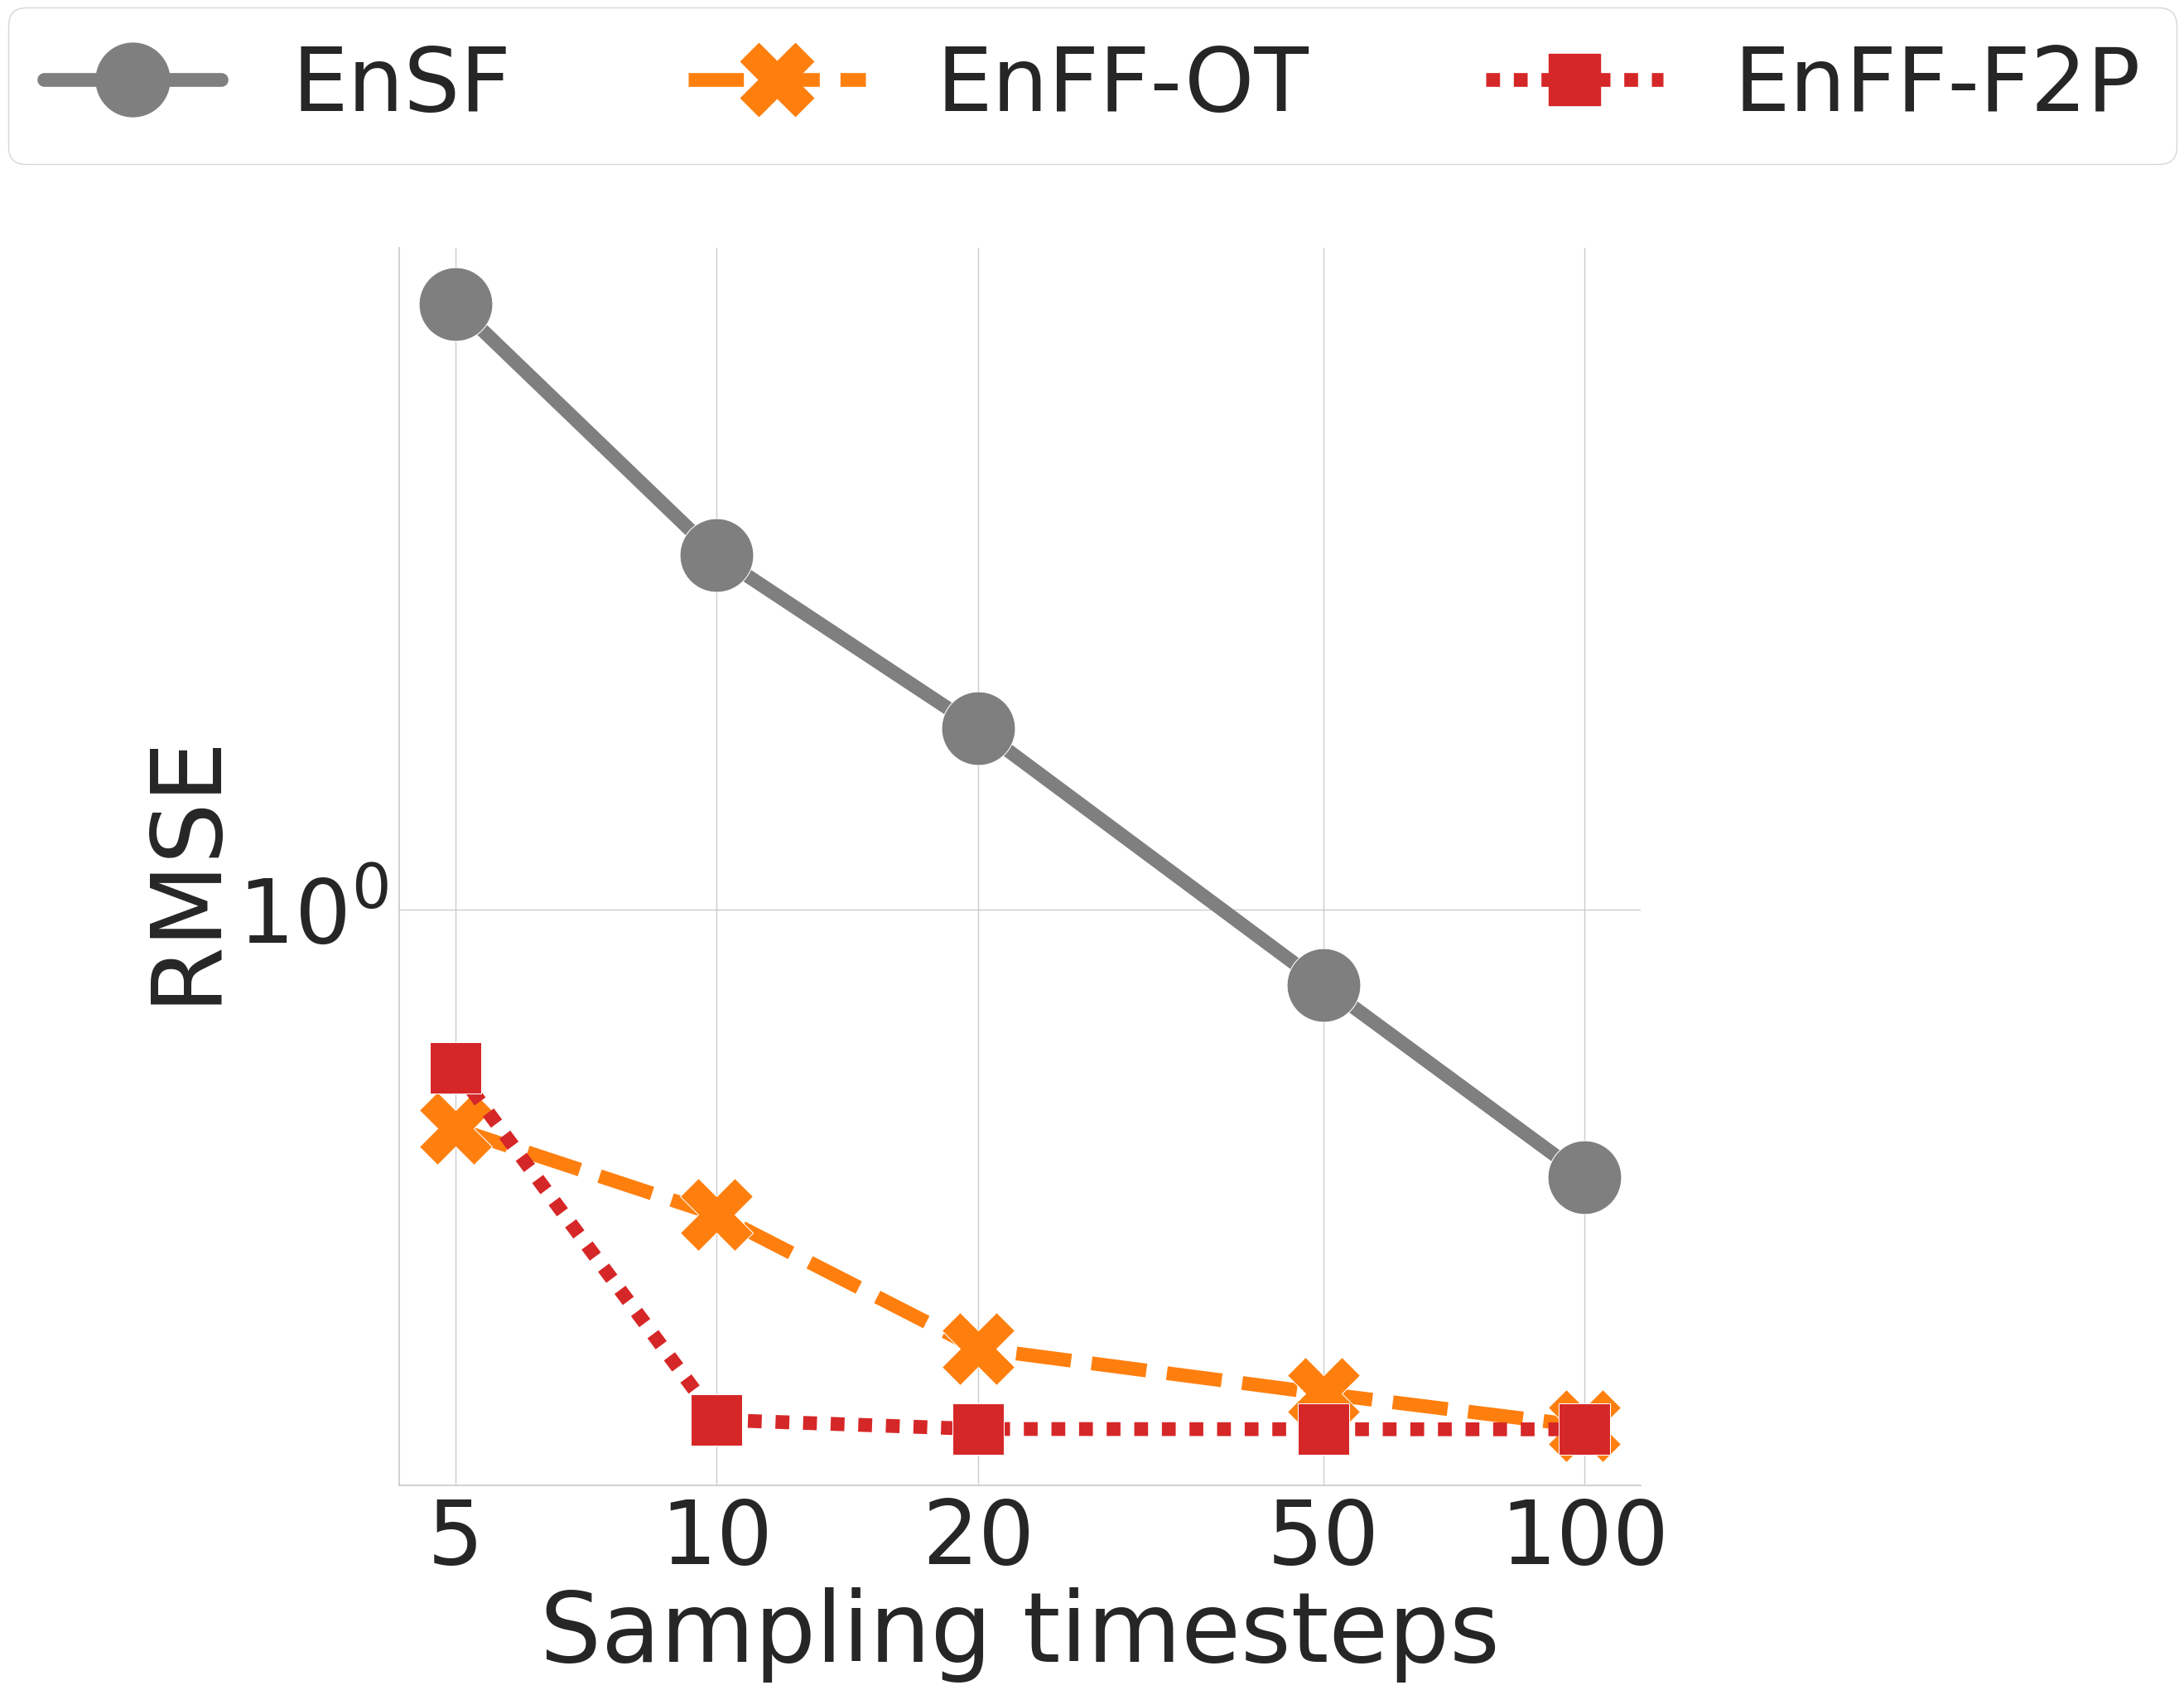

In [443]:
hue_order = ['EnSF', 'EnFF-OT', 'EnFF-F2P']
plot_data = best_rows.pl()
xticks = plot_data['sampling_time_step_count'].unique().to_numpy()
xticklabels = xticks
palette = {
    'EnSF': 'tab:gray',
    'EnFF-OT': 'tab:orange',
    'EnFF-F2P': 'tab:red',
    'BPF': 'tab:olive',
    'EnKF-PO': 'tab:pink',
    'ESRF': 'tab:purple',
    'LETKF': 'tab:green',
}
y = 'rmse'
plot_metric = (
    sns.relplot(
        kind='line',
        data=plot_data.filter(rn=1),
        x='sampling_time_step_count',
        y=y,
        hue='label',
        hue_order=hue_order,
        style='label',
        style_order=hue_order,
        palette=palette,
        markers=True,
        markersize=64,
        linewidth=12,
        height=20,
    )
    .set(
        xscale='log',
        yscale='log',
        # title=dataset_name,
        xticks=xticks,
        xticklabels=xticklabels,
        xlabel='Sampling timesteps',
        ylabel=y.upper(),
    )
)
sns.move_legend(
    plot_metric,
    loc='upper center',
    ncol=len(hue_order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)

In [426]:
plot_data.filter(label='EnFF-F2P', sampling_time_step_count=5, rn=1)

alt_id,label,sampling_time_step_count,var1,var2,rmse,crps,rn
str,str,i64,f64,f64,f64,f64,i64
"""ke12pmo8""","""EnFF-F2P""",5,-3.0,0.005,0.081962,1.862453,1


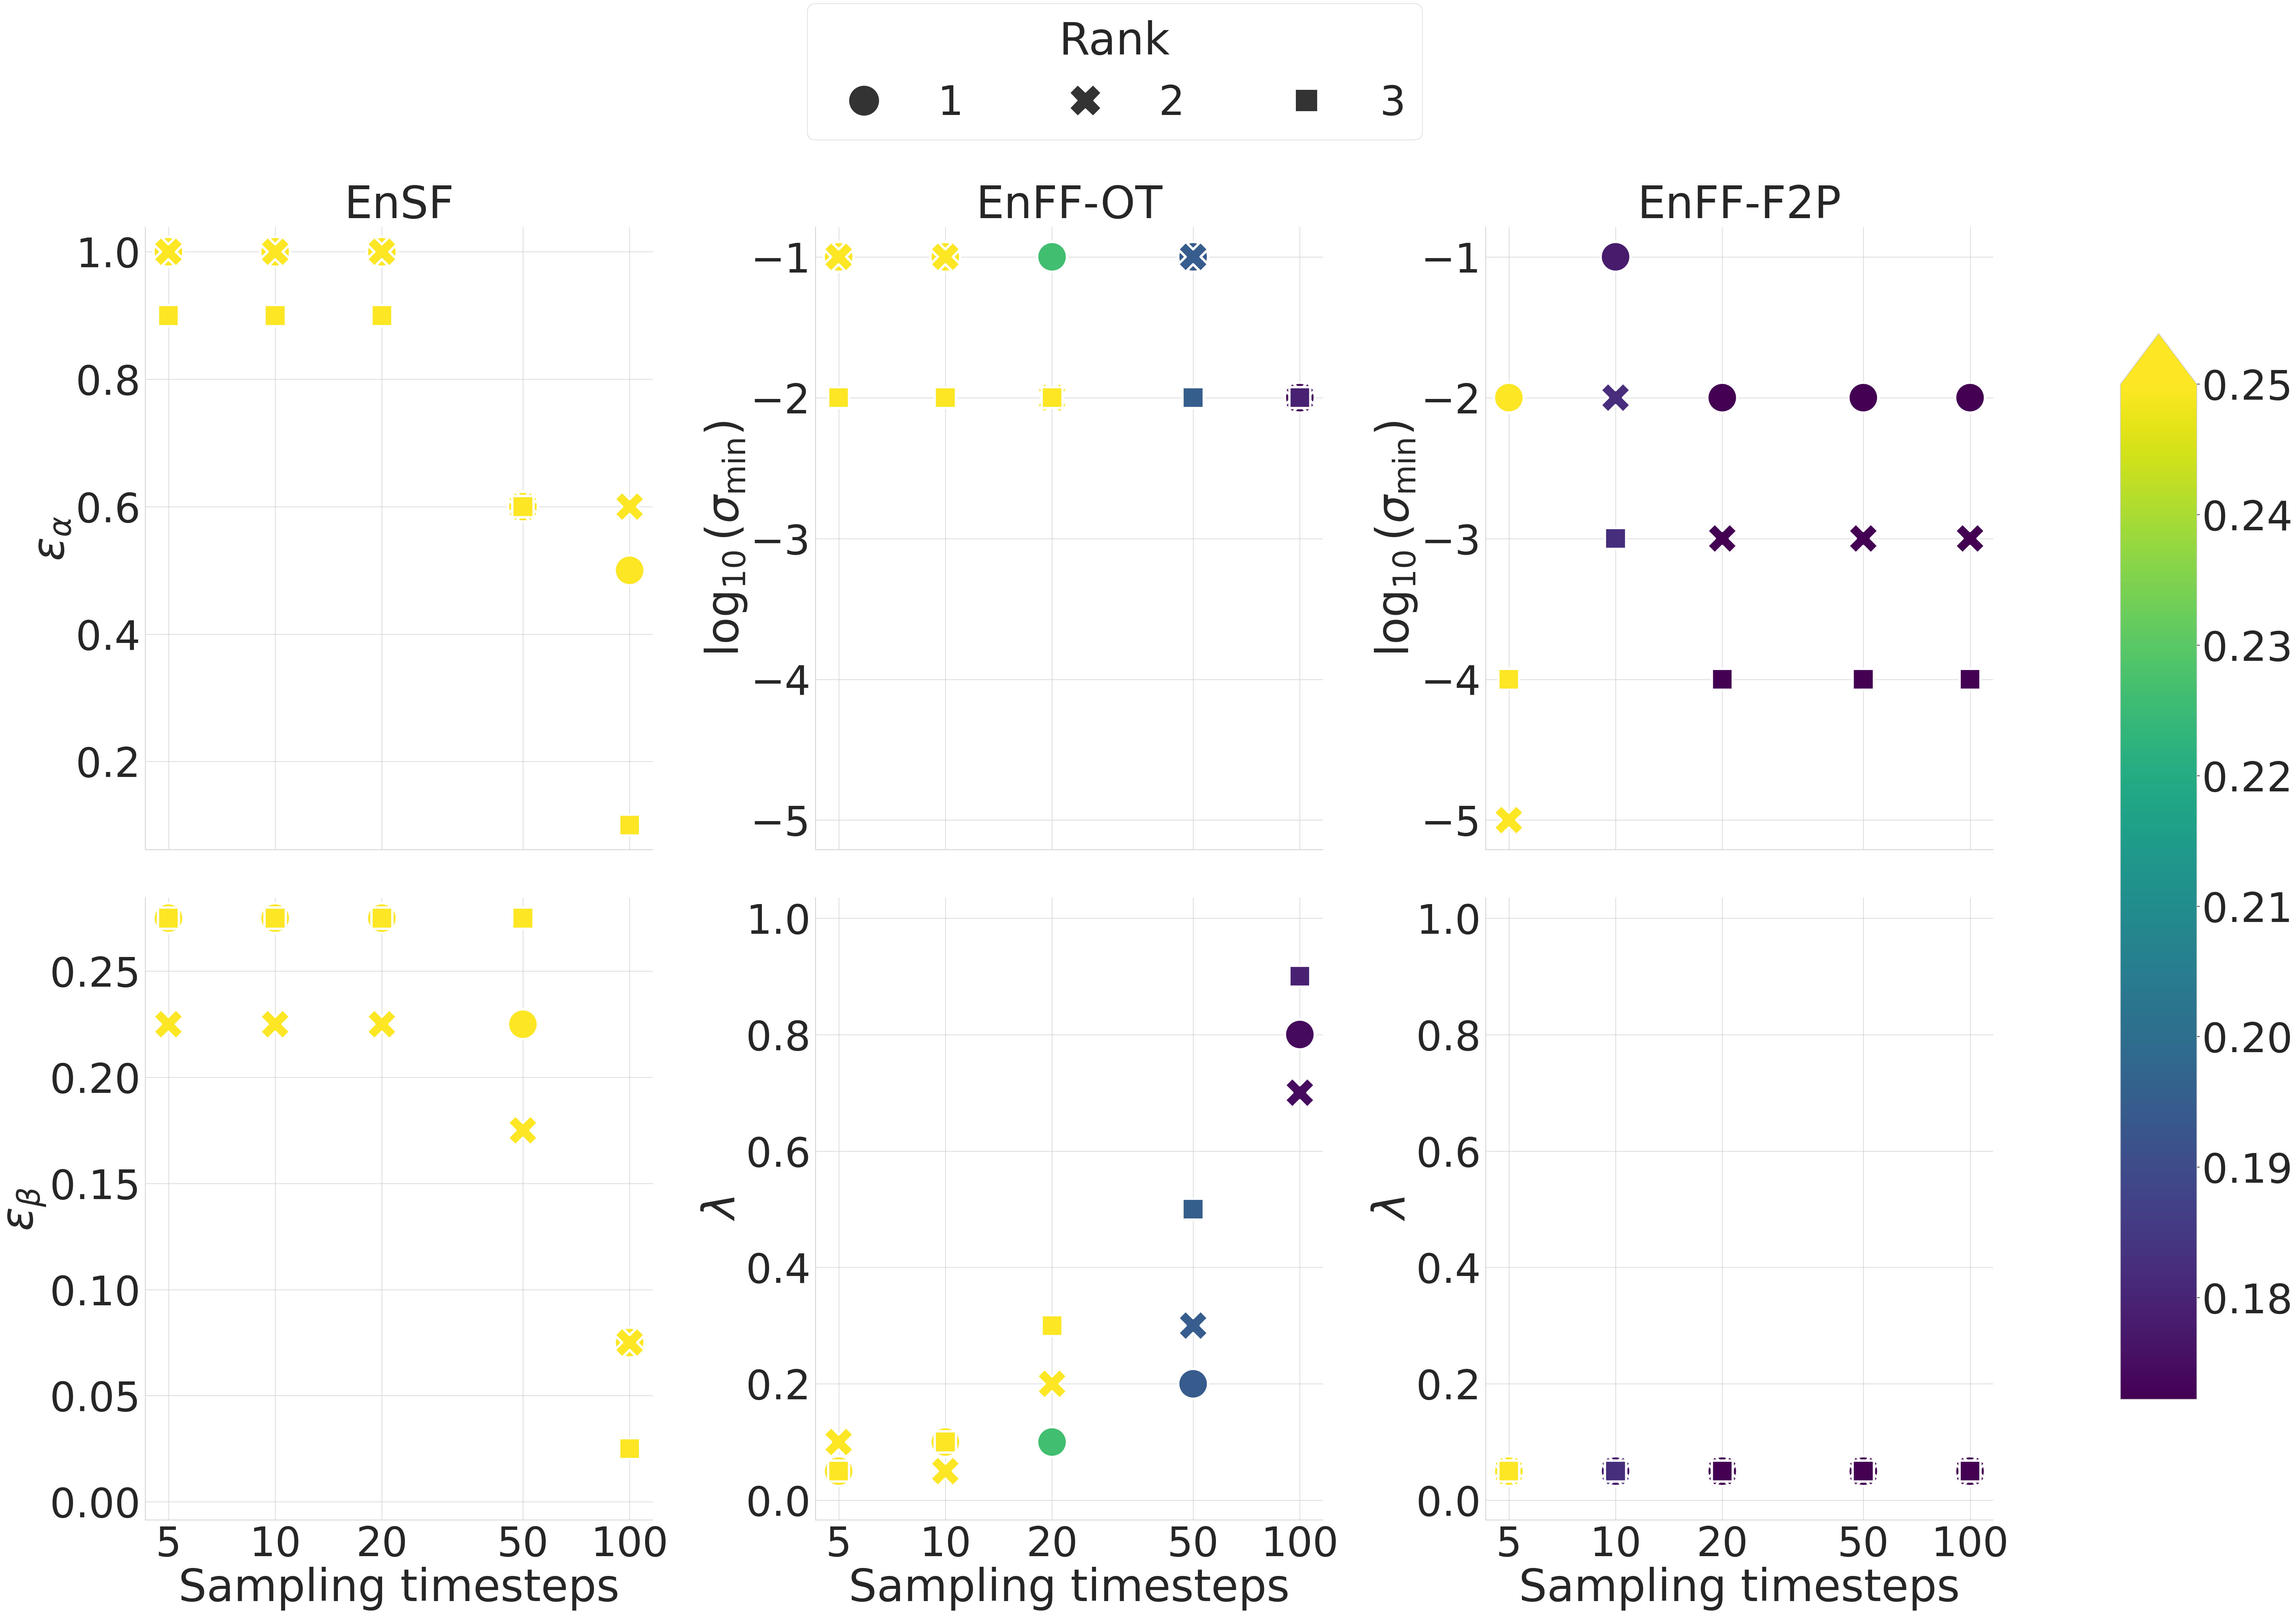

In [447]:
plot_var_data = plot_data.unpivot(
    on=['var1', 'var2'],
    index=['alt_id', 'label', 'sampling_time_step_count', 'rmse', 'rn'], 
    variable_name='var',
).with_columns(rank='rn').to_pandas()
max_rmse = .25
plot_var_data['rmse'] = plot_var_data['rmse'].clip(upper=max_rmse)
y = 'value'
norm = matplotlib.colors.Normalize(vmin=plot_var_data['rmse'].min(), vmax=max_rmse)
plot_var = (
    sns.relplot(
        kind='scatter',
        data=plot_var_data,
        x='sampling_time_step_count',
        y=y,
        row='var',
        col='label',
        col_order=hue_order,
        hue='rmse',
        palette='viridis',
        hue_norm=norm,
        # hue_order=hue_order,
        style='rank',
        # style_order=hue_order,
        # palette=palette,
        # markers=True,
        s=3200,
        # markersize=64,
        # linewidth=12,
        height=20,
        facet_kws=dict(
            sharey=False,
        ),
    )
    .set(
        xscale='log',
        # yscale='log',
        xticks=xticks,
        xticklabels=xticklabels,
        xlabel='Sampling timesteps',
        ylabel=y.upper(),
    )
    .set_titles('{col_name}')
)
legend_handles = plot_var.legend.legend_handles
plot_var.legend.remove()
plot_var.figure.legend(
    legend_handles[-3:],
    [1, 2, 3],
    loc='upper center',
    title='Rank',
    ncol=3,
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot_var.facet_data():
    ax = plot_var.axes[row, col]
    if row == 1:
        ax.set_title('')
    var_name, var_latex = var[plot_var.col_names[col]][row]
    ax.set_ylabel(var_latex)
    padding = 0.07
    var_bounds = duckdb.sql(f"""
        select min(var{row+1}), max(var{row+1}),
        from (
            select * from ensf_rows
            union
            select * from enff_ot_rows
            union
            select * from enff_f2p_rows
        )
        where label = {plot_var.col_names[col]!r}
    """).fetchall()[0]
    mid = abs(sum(var_bounds)) / 2
    ax.set_ylim(var_bounds[0] - mid * padding, var_bounds[1] + mid * padding)
    # if var_name == 'sigma_min':
    #     ax.set_yscale('log')

plot_var.tight_layout()

plot_var.figure.subplots_adjust(right=.8)
cbar_ax = plot_var.figure.add_axes([0.85, 0.17, 0.03, 0.7])
plot_var.figure.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='viridis'), cax=cbar_ax, extend='max')

In [377]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'

In [373]:
plot_data

alt_id,label,sampling_time_step_count,var1,var2,rmse,crps,rn
str,str,i64,f64,f64,f64,f64,i64
"""56zivfnl""","""EnFF-OT""",10,-1.0,0.1,0.355884,299.405432,1
"""kru30hap""","""EnFF-OT""",10,-1.0,0.05,0.38101,327.502856,2
"""13u3nhhc""","""EnFF-OT""",10,-2.0,0.1,0.47638,463.066802,3
"""jxtgrvq0""","""EnFF-F2P""",10,-1.0,0.05,0.177819,128.852704,1
"""48pftqfc""","""EnFF-F2P""",10,-2.0,0.05,0.182132,164.740946,2
…,…,…,…,…,…,…,…
"""34niguqz""","""EnSF""",20,1.0,0.225,1.875594,1373.096968,2
"""pnsewy4e""","""EnSF""",20,0.9,0.275,1.881435,1375.850603,3
"""ud5d8j3z""","""EnSF""",5,1.0,0.275,7.742977,5640.416826,1


In [382]:
px_fig = px.parallel_coordinates(
    plot_data.filter(label='EnFF-F2P')[['sampling_time_step_count', 'var1', 'var2', 'rmse']],
    color='rmse',
    labels=dict(
        rmse='RMSE',
        sampling_time_step_count='T',
        var1='var1',
        var2='var2',
    )
)
px_fig.show()